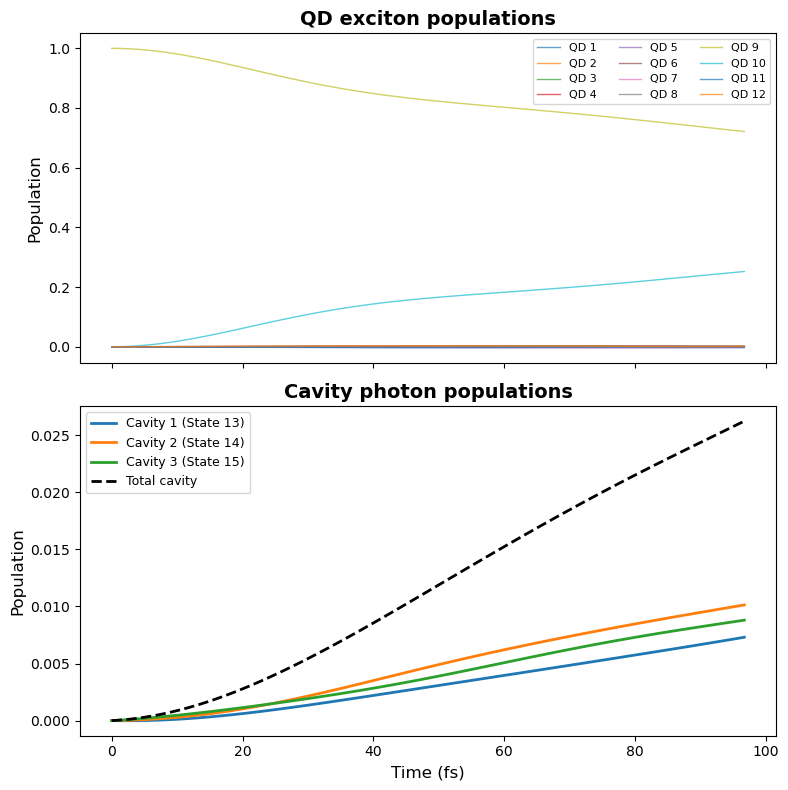

Max cavity populations:
  Cavity 1: 0.00729863
  Cavity 2: 0.0101259
  Cavity 3: 0.00879593
  Total cavity: 0.0262204


In [5]:
#!/usr/bin/env python3
"""
Read and plot population data from pop.out.

State ordering for this TC example:
- States 1-12: QD exciton states
- States 13-15: cavity photon states
"""

import numpy as np
import matplotlib.pyplot as plt

autos = 2.4188843265857e-17
n_qd = 6
nstate_per_qd = 2
n_cavity = 3
n_qd_states = n_qd * nstate_per_qd

data = np.loadtxt("pop.out")
time = data[:, 0] * autos * 1e15  # au to fs
populations = data[:, 1:]
n_states = populations.shape[1]

if n_states != n_qd_states + n_cavity:
    raise ValueError(f"Expected {n_qd_states + n_cavity} states, found {n_states}")

qd_pop = populations[:, :n_qd_states]
cavity_pop = populations[:, n_qd_states:]

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

for state in range(n_qd_states):
    axes[0].plot(time, qd_pop[:, state], label=f"QD {state + 1}", linewidth=1, alpha=0.7)
axes[0].set_ylabel("Population", fontsize=12)
axes[0].set_title("QD exciton populations", fontsize=14, fontweight="bold")
axes[0].legend(ncol=3, fontsize=8)

for cav in range(n_cavity):
    axes[1].plot(time, cavity_pop[:, cav], label=f"Cavity {cav + 1} (State {n_qd_states + cav + 1})", linewidth=2)
axes[1].plot(time, cavity_pop.sum(axis=1), "k--", label="Total cavity", linewidth=2)
axes[1].set_xlabel("Time (fs)", fontsize=12)
axes[1].set_ylabel("Population", fontsize=12)
axes[1].set_title("Cavity photon populations", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Max cavity populations:")
for cav in range(n_cavity):
    print(f"  Cavity {cav + 1}: {cavity_pop[:, cav].max():.6g}")
print(f"  Total cavity: {cavity_pop.sum(axis=1).max():.6g}")



In [3]:
np.sum(populations[:, 12:14], axis=1)

array([2.74563358e-17, 1.55725648e-06, 1.10449800e-05, 2.85559604e-05,
       5.41609812e-05, 8.79097987e-05, 1.29830339e-04, 1.79927655e-04,
       2.38180794e-04, 3.04548339e-04, 3.78969130e-04, 4.61360559e-04,
       5.51621203e-04, 6.49625808e-04, 7.55228497e-04, 8.68264916e-04,
       9.88551072e-04, 1.11588446e-03, 1.25004932e-03, 1.39082085e-03,
       1.53795913e-03, 1.69121581e-03, 1.85033597e-03, 2.01505890e-03,
       2.18512050e-03, 2.36025103e-03, 2.54017983e-03, 2.72463544e-03,
       2.91334857e-03, 3.10605010e-03, 3.30246969e-03, 3.50233337e-03,
       3.70537174e-03, 3.91131665e-03, 4.11989822e-03, 4.33085165e-03,
       4.54391483e-03, 4.75883290e-03, 4.97535348e-03, 5.19322568e-03,
       5.41220143e-03, 5.63203961e-03, 5.85250880e-03, 6.07338750e-03,
       6.29446816e-03, 6.51555315e-03, 6.73645334e-03, 6.95699196e-03,
       7.17700689e-03, 7.39635194e-03, 7.61489592e-03, 7.83252640e-03,
       8.04914845e-03, 8.26468362e-03, 8.47907455e-03, 8.69228189e-03,
      